# Exploratory Data Analysis — sample_submission.csv dataset

**Goal:** Explore the Song Lyrics dataset to understand its structure, content, and quality before building a model to classify songs by genre (`tag`).

## Questions this notebook aims to answer
1. **Class balance** — how are genres distributed? Is `tag` imbalanced?

2. **Text characteristics** — how does lyric length, vocabulary size, and repetitiveness vary by genre?
3. **Missing/dirty data** — are there empty lyrics, duplicates, non-English text, or malformed entries?
4. **Temporal trends** — how does genre popularity or lyrical style shift across `year`?
5. **Popularity signal** — does `views` correlate with genre, lyric length, or era?
6. **Vocabulary & language** — what words/n-grams are most distinctive per genre (candidates for feature engineering)?
7. **Train vs. test consistency** - o train.csv and test.csv (implied by sample_submission.csv) share similar distributions of year, views, and lyric length?
8. **Artist/genre leakage** - does the same artist appear under multiple tag values, or does the same artist show up in both train and test?
9. **Genius formatting artifacts** - lyrics scraped from Genius typically contain bracketed annotations ([Chorus], [Verse 1], [Produced by...]) 
10. **Duplicate/near-duplicate lyrics** - covers, remixes, or scraping errors can produce near-identical lyrics under different ids
11. **Structural/repetition patterns** - chorus repetition rate, line count, average line length — these often differ meaningfully by genre 
12. **Explicit/profanity rate by genre** - often strong signal for genre classification

## Approach
We will start with structural checks (shape, dtypes, nulls, duplicates), then move to  EDA (length distributions, word frequencies, TF-IDF-style genre signatures), then try to answer those specific questions and close with visualizations that motivate the modeling choices for genre classification.


# <font color='#BFD72F' size=5>1. Data Understanding</font> <a class="anchor" id="P1"></a>
  
[Back to TOC](#toc)

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

### <font color='#BFD72F' size=5>1.1 General Exploration</font> <a class="anchor" id="P11"></a>

In [5]:
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134967 entries, 0 to 134966
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   title     134965 non-null  object
 1   tag       134967 non-null  object
 2   artist    134967 non-null  object
 3   year      134967 non-null  int64 
 4   views     134967 non-null  int64 
 5   features  134967 non-null  object
 6   lyrics    134967 non-null  object
 7   id        134967 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 8.2+ MB


,year,views,id
count,134967.000000,1.349670e+05,1.349670e+05
mean,2009.467537,3.413344e+03,3.593871e+06
std,46.287743,4.192449e+04,2.323217e+06
min,1.000000,0.000000e+00,2.800000e+01
25%,2008.000000,2.200000e+01,1.414202e+06
50%,2015.000000,8.900000e+01,3.547995e+06
75%,2019.000000,4.730000e+02,5.600458e+06
max,2024.000000,3.604497e+06,7.882826e+06


In [6]:
df_test.info()
df_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33742 entries, 0 to 33741
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     33742 non-null  object
 1   artist    33742 non-null  object
 2   year      33742 non-null  int64 
 3   views     33742 non-null  int64 
 4   features  33742 non-null  object
 5   lyrics    33742 non-null  object
 6   id        33742 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1.8+ MB


,year,views,id
count,33742.000000,3.374200e+04,3.374200e+04
mean,2009.649606,3.712460e+03,3.604763e+06
std,40.044269,5.384800e+04,2.323315e+06
min,1.000000,0.000000e+00,7.000000e+00
25%,2008.000000,2.200000e+01,1.421414e+06
50%,2015.000000,8.800000e+01,3.564637e+06
75%,2019.000000,4.600000e+02,5.604923e+06
max,2023.000000,6.877777e+06,7.882715e+06


In [7]:
print(df_train.isnull().sum())
print(df_train.isnull().sum())

title       2
tag         0
artist      0
year        0
views       0
features    0
lyrics      0
id          0
dtype: int64
title       2
tag         0
artist      0
year        0
views       0
features    0
lyrics      0
id          0
dtype: int64


In [8]:
print(df_train['tag'].value_counts())

print(df_train['artist'].value_counts())


tag
pop        55742
rap        38584
rock       25332
rb          6203
misc        5640
country     3466
Name: count, dtype: int64
artist
Genius English Translations    555
The Grateful Dead               86
Emily Dickinson                 75
Abraham Lincoln                 59
OCTOBERSFULLMOON                58
                              ... 
Holy Mattress Money              1
Tony Hood                        1
LuisVZ                           1
Inceptus                         1
TheGodlyRiskTakers               1
Name: count, Length: 74916, dtype: int64


In [9]:
# Checking empty and missing review texts
print("missing text lyrics:", df_train['lyrics'].isnull().sum())
print("empty text lyrics:", (df_train['lyrics'].str.strip() == '').sum())

missing text lyrics: 0
empty text lyrics: 0


In [10]:
# checking duplicates and empty texts

duplicates = df_train.duplicated(subset=['lyrics']).sum()
empty = (df_train['lyrics'].str.strip() == '').sum()
print(f"duplicates: {duplicates}")
print(f"empty songs : {empty}")



duplicates: 178
empty songs : 0


In [11]:
# ids of the duplicated songs so we can remove them
duplicated_ids = df_train.loc[df_train.duplicated(subset=['lyrics']), 'id'].tolist()
len(duplicated_ids)


178

In [12]:
#analysing the longest lyrics + 100 longest lyrics and comparing to the shortest ones


In [13]:
#getting the list of unique artist so we can take the non musicians
print(df_train['artist'].nunique())

print(df_train['artist'].unique().tolist())

74916
['Tony Molina', 'Reece Lett', 'Elliot (DNK)', 'Katie Armiger', 'John Campbell Munro', 'HoustonBlake', 'Della Marie', 'YRM Bear', 'Lil_Sauce_Goblin', 'Tom Robinson', 'Taj Ahkel', 'Lewis Del Mar', '2shanez', 'YOUNG DIAMOND', 'Reel Big Fish', 'Swift (Band)', 'Kuinn', 'Stephen Marley', 'The Aubreys', 'blackbear', 'X-Sinner', 'As I Lay Dying', 'Hercules & Love Affair', 'Ty Segall', 'Ricky Van Shelton', 'Martin the Misfit', 'Johnny Mathis', 'Current Joys', 'Jerry.C [UpToNoGood]', 'Nu Deja-Vu', 'Arber Lutolli', 'Emi Meyer', 'Tally Hall', 'Lune (SVE)', 'Maycoabarrios', 'Bruisers', 'AdzMilli', 'The Oak Ridge Boys', 'Is0kenny', 'Cleveland Bound Death Sentence', 'Significantly', 'Cinder Road', 'Fellwarden', 'The Neverending Mixtape', 'Aaron Malone', 'Demolition Train', '888 Blue', 'Morrissey', 'Andrews Right', 'Everything Everything', 'Standing on the Corner', '3rd Wave', 'Josh Ritter', 'Verse Simmonds', 'Dana Lyons', 'Linda Eder', 'Nameless', 'Bass Astral x Igo', 'Kenny Bands', 'Ihsahn', '

## <font color='#BFD72F' size=5>1.2 Visualization of the data</font> <a class="anchor" id="P12"></a>


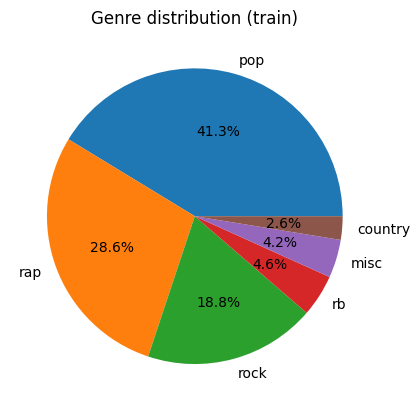

In [14]:
# Estrutura das categorias nos datasets

df_train['tag'].value_counts().plot.pie(autopct ='%1.1f%%', ylabel = '')
plt.title('Genre distribution (train)')
plt.show()

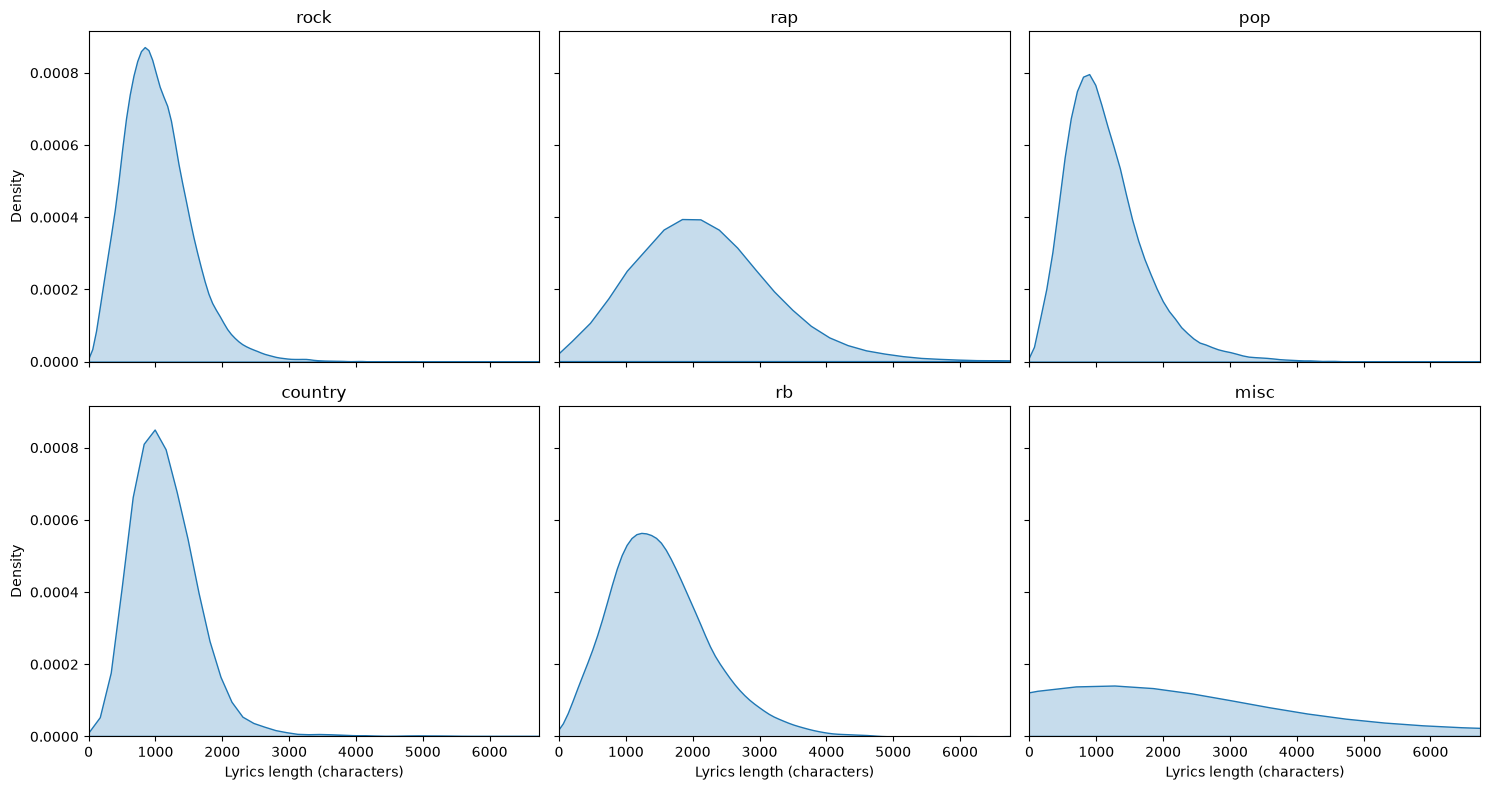

In [ ]:
# distributions of lyrics size per music genre

tags = df_train['tag'].unique()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

for ax, tag in zip(axes.flatten(), tags):
    subset = df_train[df_train['tag'] == tag]
    sns.kdeplot(data=subset, x='lyrics_length', ax=ax, fill=True)
    ax.set_title(tag)
    ax.set_xlabel('Lyrics length (characters)')

plt.xlim(0, df_train['lyrics_length'].quantile(0.99))  # clip long tail
plt.tight_layout()
plt.savefig('lyrics_length_by_tag.png', dpi=150)
plt.show()
